# **Mental Health Analyst with IBM Granite: Stress Dataset**

- **Name:** Christian Julianto Sayono
- **Email:** christianjulianto1707@gmail.com
- **Dataset Link (Kaggle):** https://www.kaggle.com/datasets/mdsultanulislamovi/student-stress-monitoring-datasets

## 1. Persiapan Lingkungan

### Instalasi Package

In [ ]:
!pip install replicate langchain langchain-community langchain-experimental pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.2/209.2 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.9 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


### Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from google.colab import userdata
from langchain_community.llms import Replicate
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent

### Setup Koneksi Replicate

In [ ]:
api_token = userdata.get("api_token")
os.environ["REPLICATE_API_TOKEN"] = api_token

## 3. Pengambilan Data

### Load Dataset

In [ ]:
# Upload manual via Colab
from google.colab import files
uploaded = files.upload()

Saving Stress_Dataset.csv to Stress_Dataset.csv


In [ ]:
# Buat folder untuk menyimpan plot
os.makedirs("/content/plots", exist_ok=True)

In [ ]:
# Misalnya file bernama Stress_Dataset.csv
df = pd.read_csv("Stress_Dataset.csv")

In [ ]:
# Lihat data awal
df.head()

,Gender,Age,Have you recently experienced stress in your life?,Have you noticed a rapid heartbeat or palpitations?,Have you been dealing with anxiety or tension recently?,Do you face any sleep problems or difficulties falling asleep?,Have you been dealing with anxiety or tension recently?.1,Have you been getting headaches more often than usual?,Do you get irritated easily?,Do you have trouble concentrating on your academic tasks?,...,Are you facing any difficulties with your professors or instructors?,Is your working environment unpleasant or stressful?,Do you struggle to find time for relaxation and leisure activities?,Is your hostel or home environment causing you difficulties?,Do you lack confidence in your academic performance?,Do you lack confidence in your choice of academic subjects?,Academic and extracurricular activities conflicting for you?,Do you attend classes regularly?,Have you gained/lost weight?,Which type of stress do you primarily experience?
0,0,20,3,4,2,5,1,2,1,2,...,3,1,4,1,2,1,3,1,2,Eustress (Positive Stress) - Stress that motiv...
1,0,20,2,3,2,1,1,1,1,4,...,3,2,1,1,3,2,1,4,2,Eustress (Positive Stress) - Stress that motiv...
2,0,20,5,4,2,2,1,3,4,2,...,2,2,2,1,4,1,1,2,1,Eustress (Positive Stress) - Stress that motiv...
3,1,20,3,4,3,2,2,3,4,3,...,1,1,2,1,2,1,1,5,3,Eustress (Positive Stress) - Stress that motiv...
4,0,20,3,3,3,2,2,4,4,4,...,2,3,1,2,2,4,2,2,2,Eustress (Positive Stress) - Stress that motiv...


## 4. Inisialisasi IBM Granite

In [ ]:
llm = Replicate(
    model="ibm-granite/granite-3.3-8b-instruct",
    model_kwargs={
        "temperature": 0.2, # tetap fokus
        "top_p": 0.8, # sampling lebih ketat
        "top_k": 20, # batasi variasi kata
        "repetition_penalty": 1.05, # cegah pengulangan
        "random_seed": 42,
        "max_new_tokens": 50 # batasi panjang output
    }
)


## 5. Analisis Data

### Deskripsi Data

In [ ]:
print("\n=== DESKRIPSI DATASET ===\n")

n_rows, n_cols = df.shape
dtypes = df.dtypes.astype(str).to_dict()
head5 = df.head(5).to_dict(orient="records")

# Cari kolom gender
gender_col = None
for cand in ["gender", "Gender"]:
    if cand in df.columns:
        gender_col = cand
        break

# Cari kolom survey (nilai mostly 1–5)
numeric_cols = df.select_dtypes(include="number").columns.tolist()
survey_cols = []
for c in numeric_cols:
    if c == gender_col:
        continue
    s = df[c].dropna()
    if len(s) == 0:
        continue
    if ((s >= 1) & (s <= 5)).mean() >= 0.95:
        survey_cols.append(c)

print(f"Jumlah baris: {n_rows}")
print(f"Jumlah kolom: {n_cols}")
print(f"Kolom gender: {gender_col}")
print(f"Kolom survey terdeteksi: {survey_cols[:10]} ...")

prompt = f"""
Dataset mental health stress:
- Jumlah baris: {n_rows}
- Jumlah kolom: {n_cols}
- Kolom gender: {gender_col}
- Kolom survei (skala 1-5): {survey_cols}
- Contoh 5 baris: {head5}

Buat ringkasan singkat (maks 200 kata) dalam bahasa Indonesia
tentang struktur dataset ini. Sertakan catatan tentang encoding gender (0=Pria,1=Wanita).
"""
desc = llm.invoke(prompt)
print(desc)


=== DESKRIPSI DATASET ===

Jumlah baris: 843
Jumlah kolom: 26
Kolom gender: Gender
Kolom survey terdeteksi: ['Have you recently experienced stress in your life?', 'Have you noticed a rapid heartbeat or palpitations?', 'Have you been dealing with anxiety or tension recently?', 'Do you face any sleep problems or difficulties falling asleep?', 'Have you been dealing with anxiety or tension recently?.1', 'Have you been getting headaches more often than usual?', 'Do you get irritated easily?', 'Do you have trouble concentrating on your academic tasks?', 'Have you been feeling sadness or low mood?', 'Have you been experiencing any illness or health issues?'] ...
Dataset ini berisi informasi tentang kesehatan mental dan stres diantara mahasiswa, dengan jumlah baris 843 dan 26 kolom. Kolom 'Gender' mengidentifikasi jenis laki-laki (0) atau perempuan (1). Kolom lainnya mengukur berbagai aspek stres seperti pengalaman stres terkini, gejala fisik (seperti seringkalan kejang dan masalah tidur), g

### Cek Missing Value

In [ ]:
print("\n=== CEK DATA HILANG ===\n")
missing_counts = df.isna().sum()
missing_percent = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({"count": missing_counts, "percent": missing_percent})
print(missing_df[missing_df["count"] > 0])

prompt = f"""
Ada data hilang berikut:
{missing_df[missing_df['count']>0].to_dict(orient='index')}

Sarankan strategi penanganan per kolom (drop/imputasi),
khusus untuk data survei mental health.
Jawab ringkas dalam bahasa Indonesia (bullet points).
"""
missing_text = llm.invoke(prompt)
print(missing_text)


=== CEK DATA HILANG ===

Empty DataFrame
Columns: [count, percent]
Index: []
Berikut adalah beberapa strategi penanganan data yang hilang berdasarkan kolom untuk data survei mental health:

- **Imputasi Menggunakan Mean/Median/Mode:**
  - Jika data hilang terjadi pada kolom yang mengukur tingkat kecemasan, kebahagiaan, atau kesehatan mental lainnya, pilihan yang tepat adalah menggunakan rata-rata (mean), media (median), atau mode dari nilai-nilai yang tersedia untuk mengimputasi nilai hilang.

- **Imputasi Menggunakan Regresi:**
  - Metode regresi, seperti regresi kriging atau regresi kusar, dapat digunakan untuk mengimputasi data hilang berdasarkan nilai-nilai yang tersedia di kolom lain yang berkaitan dengan faktor-faktor mental health.

- **Imputasi Menggunakan Metode Statistik Lainnya:**
  - **Imputasi Multiple:** Menggunakan beberapa metode statistik untuk mengimputasi, misalnya menggunakan korelasi antar kolom dengan data yang tersedia.
  - **Imputasi Menggunakan Model Bayes:** 

### Klasifikasi Tingkat Stress

In [ ]:
print("\n=== KLASIFIKASI LEVEL STRESS ===\n")

df["stress_mean"] = df[survey_cols].mean(axis=1)

def classify(val):
    if val <= 2.0:
        return "Low"
    elif val < 3.5:
        return "Moderate"
    else:
        return "High"

df["stress_label"] = df["stress_mean"].apply(classify)

class_counts = df["stress_label"].value_counts(normalize=False)
class_percent = df["stress_label"].value_counts(normalize=True) * 100
summary = pd.DataFrame({"count": class_counts, "percent": class_percent.round(2)})
print(summary)

prompt = f"""
Hasil klasifikasi stress responden:
{summary.to_dict(orient='index')}

Jelaskan dalam bahasa Indonesia:
1) Jumlah & persentase tiap kelas
2) Makna distribusi ini (misal mayoritas Moderate)
3) Implikasi untuk kesehatan mental mahasiswa
"""
classification_text = llm.invoke(prompt)
print(classification_text)


=== KLASIFIKASI LEVEL STRESS ===

              count  percent
stress_label                
Moderate        754    89.44
Low              57     6.76
High             32     3.80
1. Jumlah dan persentase tiap kelas:
   - Kelas Stres Moderate: 754 responden, sekitar 89.44%
   - Kelas Stres Rendah: 57 responden, sekitar 6.76%
   - Kelas Stres Tinggi: 32 responden, sekitar 3.8%

2. Makna distribusi ini:
   Distribusi klasifikasi stres tersebut menunjukkan bahwa mayoritas responden (89.44%) mengalami stres moderate. Kelas stres rendah dan tinggi masing-masing dianggap sebagai minoritas dengan persentase 6.76% dan 3.8%. Ini sifatnya menunjukkan bahwa stres moderate menjadi faktor utama yang dihadapi oleh mahasiswa dalam kajian ini.

3. Implikasi untuk kesehatan mental mahasiswa:
   Hasil klasifikasi stres yang dominan terjadi pada kelas moderate menunjukkan bahwa sebagian besar mahasiswa mengalami tingkat stres yang dapat dianggap sebagai 'stres normal' atau 'stres akademik'. Stres moderat

### Visualisasi

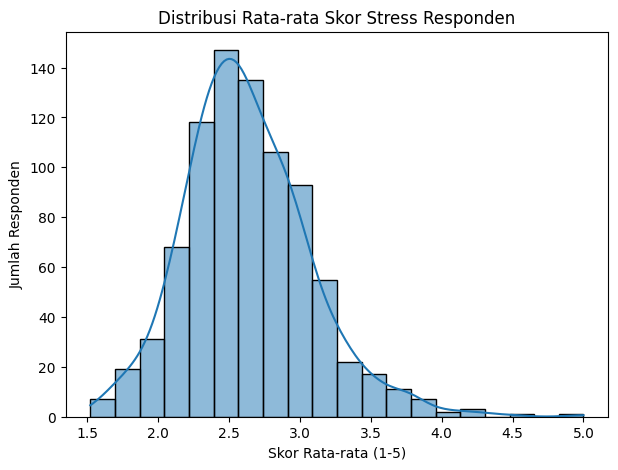

In [ ]:
# Histogram distribusi stress_mean
plt.figure(figsize=(7,5))
sns.histplot(df["stress_mean"], bins=20, kde=True)
plt.title("Distribusi Rata-rata Skor Stress Responden")
plt.xlabel("Skor Rata-rata (1-5)")
plt.ylabel("Jumlah Responden")
plt.savefig("/content/plots/stress_mean_hist.png", dpi=150)
plt.show()

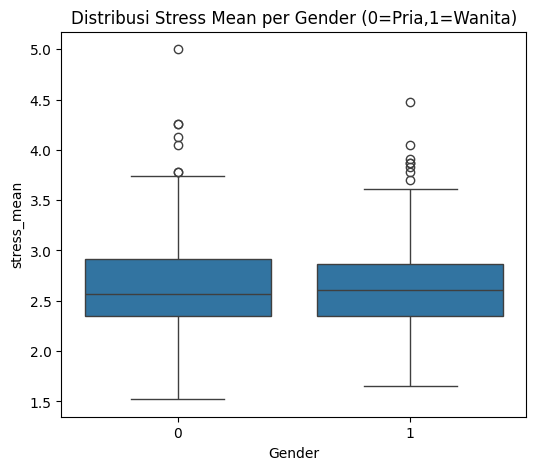

In [ ]:
# Boxplot per gender
plt.figure(figsize=(6,5))
sns.boxplot(x=gender_col, y="stress_mean", data=df)
plt.title("Distribusi Stress Mean per Gender (0=Pria,1=Wanita)")
plt.savefig("/content/plots/stress_mean_by_gender.png", dpi=150)
plt.show()

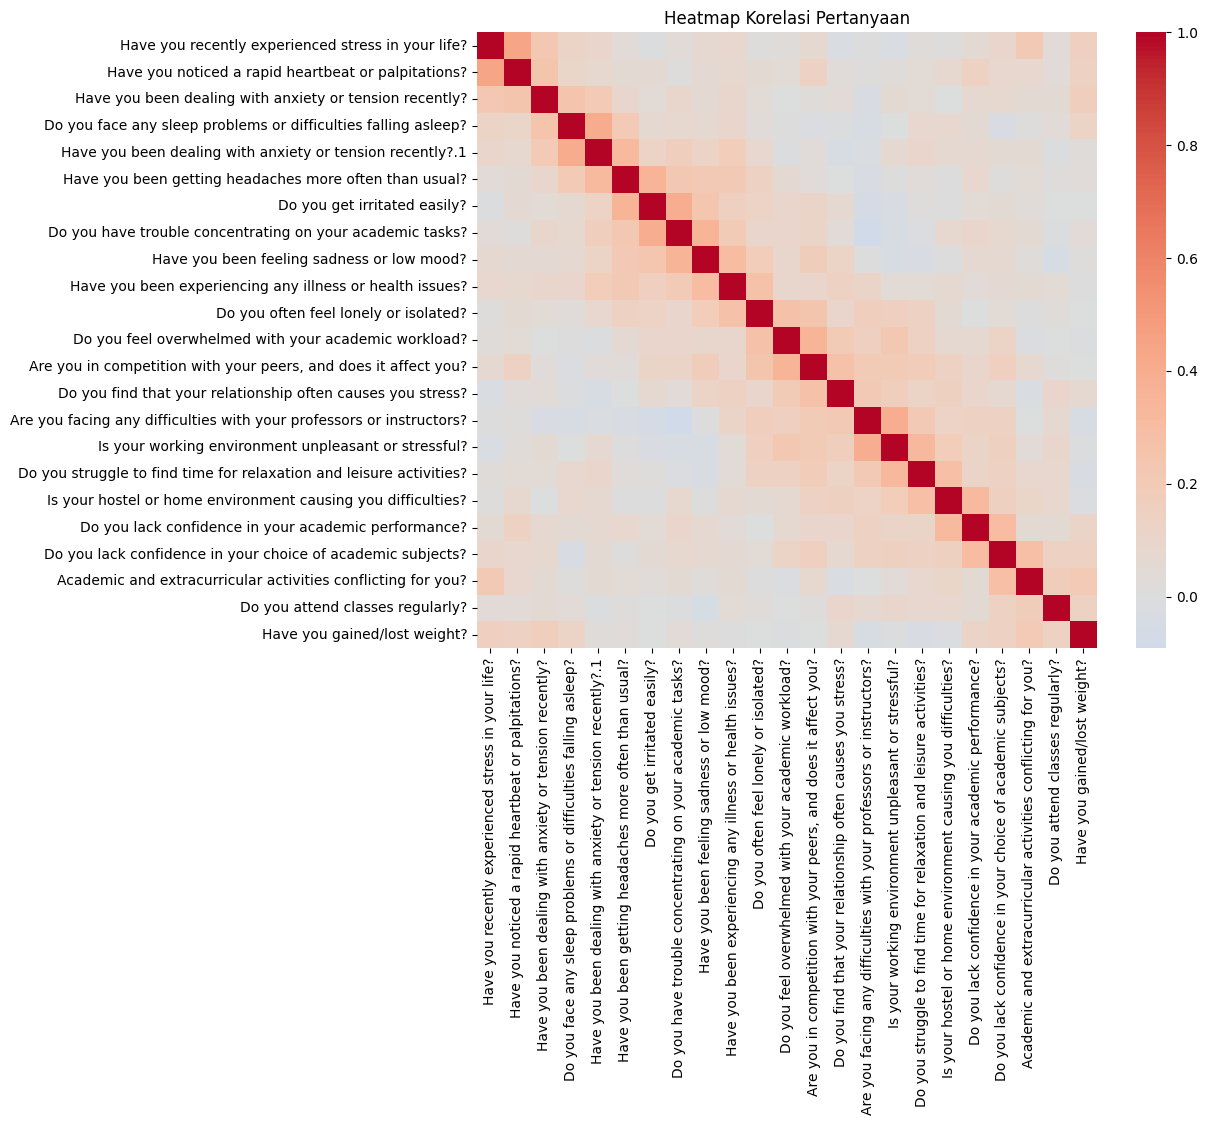

In [ ]:
# Heatmap korelasi antar pertanyaan
plt.figure(figsize=(10,8))
corr = df[survey_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Heatmap Korelasi Pertanyaan")
plt.savefig("/content/plots/corr_heatmap.png", dpi=150)
plt.show()

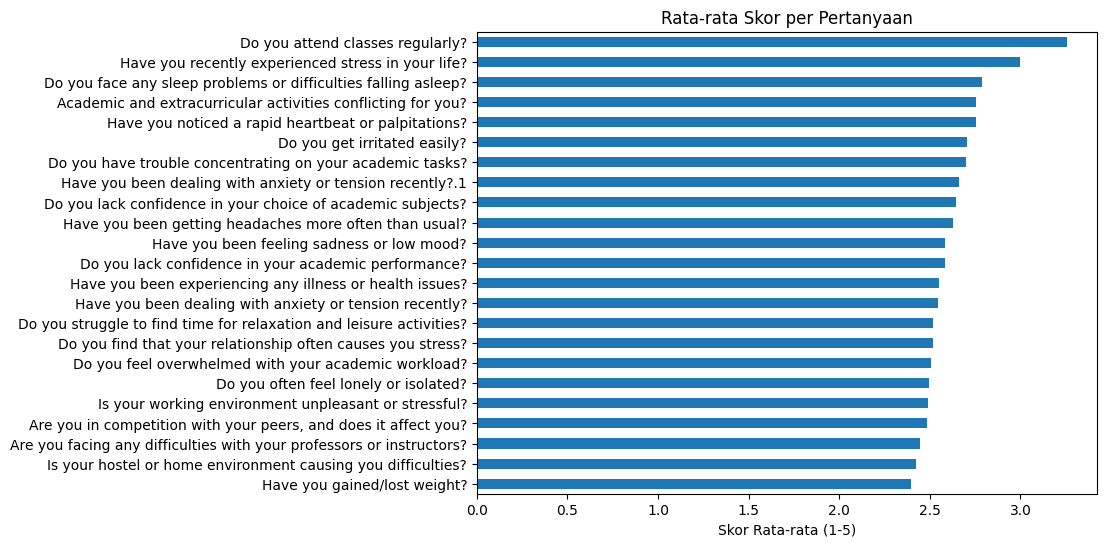

In [ ]:
# Bar chart rata-rata per pertanyaan
means = df[survey_cols].mean().sort_values(ascending=True)
plt.figure(figsize=(8,6))
means.plot(kind="barh")
plt.title("Rata-rata Skor per Pertanyaan")
plt.xlabel("Skor Rata-rata (1-5)")
plt.savefig("/content/plots/question_means.png", dpi=150)
plt.show()

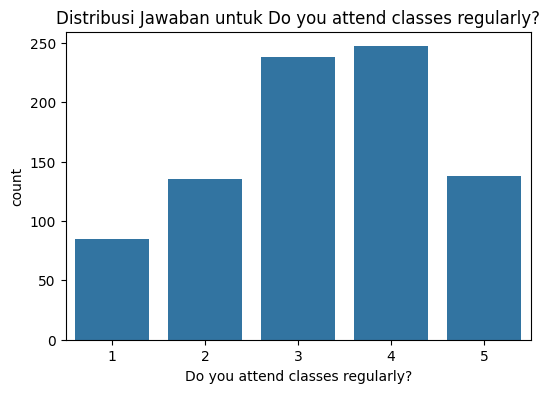

In [ ]:
# Distribusi jawaban pertanyaan dengan mean tertinggi
top_q = means.index[-1]
plt.figure(figsize=(6,4))
sns.countplot(x=df[top_q])
plt.title(f"Distribusi Jawaban untuk {top_q}")
plt.savefig("/content/plots/top_question_dist.png", dpi=150)
plt.show()

## 6. Insight & Rekomendasi

In [ ]:
print("\n=== TEMUAN & REKOMENDASI ===\n")

prompt = f"""
Ringkas hasil analisis dataset mental health stress berikut:
- Distribusi kelas stress: {summary.to_dict(orient='index')}
- Pertanyaan dengan skor rata-rata tertinggi: {top_q} (mean={means[top_q]:.2f})
- Rata-rata stress pria={df[df[gender_col]==0]['stress_mean'].mean():.2f}, wanita={df[df[gender_col]==1]['stress_mean'].mean():.2f}

Tulis jawaban dalam Bahasa Indonesia dengan format WAJIB berikut:
Temuan Utama (3 poin)
- ...

Rekomendasi (3 poin)
- ...

Prioritas
Tuliskan 2–3 kalimat menjelaskan rekomendasi mana yang paling penting dilakukan lebih dulu dan alasannya.
"""

insight = llm.invoke(prompt)
print(insight)


=== TEMUAN & REKOMENDASI ===

Temuan Utama (3 poin):

1. Distribusi kelas stress terbentuk dengan 'Moderate' sebagai kelas dominan (89.44%), diikuti oleh 'Low' (6.76%) dan 'High' (3.8%).
2. Pertanyaan "Apakah Anda menghadiri kelas secara teratur?" memiliki skor rata-rata tertinggi (3.26), menunjukkan hubungan dengan stress mental.
3. Rata-rata stress pria dan wanita sama sama sekitar 2.62 dan 2.64, menunjukkan kesamaan pengalaman stres pada jenis kelamin tersebut.

Rekomendasi (3 poin):

1. Penting untuk mengembangkan program edukasi dan sosialisasi terkait pentingnya menghadiri kelas secara teratur, berdasarkan pertanyaan dengan skor rata-rata tertinggi.
2. Implementasikan intervensi terapi mental terpadu, khususnya bagi subklas 'Moderate' stress, untuk mencegah peningkatan kadar stres menjadi kelas 'High'.
3. Lakukan penelitian lebih lanjut terkait perbedaan rata-rata stres antara pria dan wanita untuk mengembangkan strategi intervensi yang lebih spesifik.

Prioritas:

1. Rekomendas